## CIFAR-10
The CIFAR-10 dataset is a widely used benchmark dataset in the field of computer vision and machine learning. It stands for the Canadian Institute for Advanced Research (CIFAR), which sponsored the dataset's creation. The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 different classes, with 6,000 images per class. The classes are as follows:

Airplane
Automobile
Bird
Cat
Deer
Dog
Frog
Horse
Ship
Truck
Each image in the dataset belongs to one of these categories. The dataset is split into a training set with 50,000 images and a test set with 10,000 images. It is widely used for image classification tasks, serving as a standard benchmark for evaluating the performance of machine learning models on visual recognition tasks. The relatively small size of the images makes it a convenient dataset for experimenting with and testing algorithms.

## CNN Model Building

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load and preprocess the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training: ", y_train)
print("Testing: ", y_test)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 473s 3us/step
Training:  [[6]
 [9]
 [9]
 ...
 [9]
 [1]
 [1]]
Testing:  [[3]
 [8]
 [8]
 ...
 [5]
 [1]
 [7]]


In [3]:
X_train, X_test = X_train / 255.0, X_test / 255.0  # Normalize pixel values to between 0 and 1
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print("Training: ", y_train)
print("Testing: ", y_test)

Training:  [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]
Testing:  [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]


In [5]:
# Define the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the model
history = model.fit(X_train, y_train, epochs=2, validation_data=(X_test, y_test))

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.3515 - loss: 1.7509 - val_accuracy: 0.5396 - val_loss: 1.2826
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5745 - loss: 1.1908 - val_accuracy: 0.5992 - val_loss: 1.1609


In [5]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
train_loss, train_accuracy = model.evaluate(X_train, y_train)

print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
print(f"\nTraining Accuracy: {train_accuracy * 100:.2f}%")

1563/1563 [==============================] - 21s 13ms/step - loss: 1.0486 - accuracy: 0.6306

Test Accuracy: 60.61%

Training Accuracy: 63.06%


True Label: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
1/1 [==============================] - 0s 29ms/step
Predicted Label: [[0.00830663 0.00174647 0.03160787 0.0365911  0.02732166 0.0212987
  0.86807823 0.00095438 0.00258501 0.00151002]]


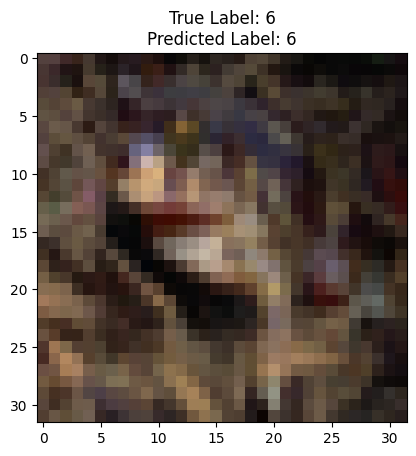

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Select a single image from the test set
sample_index = 3984  # Change this index to see predictions for different images
sample_image = X_test[sample_index]
true_label = y_test[sample_index]
print("True Label:",true_label)
true_label = np.argmax(y_test[sample_index])

# Reshape the image to match the input shape expected by the model
input_image = np.expand_dims(sample_image, axis=0)

# Make a prediction
predicted_probs = model.predict(input_image)
predicted_label = predicted_probs
print("Predicted Label:",predicted_label)
predicted_label = np.argmax(predicted_probs)

# Display the true and predicted labels along with the image
plt.imshow(sample_image)
plt.title(f"True Label: {true_label}\nPredicted Label: {predicted_label}")
plt.show()